# SharePlate – Food Safety & Urgency Intelligence Engine

## Objective
Build an intelligent food donation assessment system that predicts whether donated food is safe for redistribution and prioritizes donations based on urgency for pickup and delivery.

## Business Problem
Food donations vary in freshness, storage conditions, transportation time, environmental exposure, and perishability. NGOs often struggle to determine which donations should be collected and redistributed first. SharePlate helps automate food safety assessment and donation prioritization.

## Inputs
- Food Item
- Food Category
- Preparation Method
- Storage Condition
- Packaging Type
- Temperature
- Humidity
- Hours Since Prepared
- Transport Time
- Distance
- Quantity
- Season
- Event Type
- City Tier
- Perishability Score
- Estimated Shelf Life

## Outputs
### Machine Learning Prediction
- Safe to Donate (Yes / Review / No)

### Business Intelligence Outputs
- Remaining Shelf Life
- Urgency Score (0–100)
- Urgency Level (Low / Medium / High / Critical)
- Pickup Priority Ranking
- Recommended Action

## Machine Learning Model
- CatBoost Multi-Class Classifier
- Accuracy: 92.35%
- Weighted F1 Score: ~0.92

## Business Rules Engine
- Remaining Shelf Life Calculation
- Urgency Scoring Engine
- Donation Prioritization Logic

## Impact
- Improves food redistribution efficiency
- Reduces food wastage
- Helps NGOs prioritize time-sensitive donations
- Enables faster and safer food rescue operations

In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)
import warnings
warnings.filterwarnings("ignore")

In [4]:
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Shape :", df.shape)

df.head()

Saving shareplate_food_spoilage_dataset.csv to shareplate_food_spoilage_dataset.csv
Shape : (50000, 19)


,donation_id,food_item,food_category,preparation_method,storage_condition,packaging_type,temperature_c,humidity_percent,hours_since_prepared,estimated_transport_time_hr,distance_km,quantity_kg,season,event_type,city_tier,perishability_score,estimated_shelf_life_hr,spoilage_risk_label,safe_to_donate
0,SP133553,Dal,Cooked Meal,Packaged,Refrigerated,Covered Container,5.8,33.5,0.88,1.61,21.49,26.46,Winter,Canteen,Tier-2,5,21.98,Low,Yes
1,SP109427,Curd,Dairy,Packaged,Room Temperature,Foil Pack,22.7,63.4,5.01,0.32,5.41,19.87,Spring,Canteen,Tier-1,4,8.15,Medium,Yes
2,SP100199,Chicken Curry,Meat-Based Meal,Boiled,Insulated Container,Sealed Pack,30.2,53.4,18.60,2.27,45.70,3.33,Summer,Restaurant Surplus,Tier-1,5,8.82,High,No
3,SP112447,Chapati,Bakery,Boiled,Room Temperature,Foil Pack,34.3,50.8,28.45,0.87,9.84,5.43,Summer,Canteen,Tier-3,2,27.74,Medium,Review
4,SP139489,Fish Curry,Meat-Based Meal,Packaged,Room Temperature,Open Tray,34.7,50.1,4.13,3.61,28.86,25.73,Summer,Restaurant Surplus,Tier-2,5,4.14,Medium,Review


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   donation_id                  50000 non-null  object 
 1   food_item                    50000 non-null  object 
 2   food_category                50000 non-null  object 
 3   preparation_method           50000 non-null  object 
 4   storage_condition            50000 non-null  object 
 5   packaging_type               50000 non-null  object 
 6   temperature_c                50000 non-null  float64
 7   humidity_percent             50000 non-null  float64
 8   hours_since_prepared         50000 non-null  float64
 9   estimated_transport_time_hr  50000 non-null  float64
 10  distance_km                  50000 non-null  float64
 11  quantity_kg                  50000 non-null  float64
 12  season                       50000 non-null  object 
 13  event_type      

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
donation_id,50000,50000,SP105311,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
food_item,50000,18,Cooked Rice,4474,NaN,NaN,NaN,NaN,NaN,NaN,NaN
food_category,50000,9,Cooked Meal,15522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
preparation_method,50000,6,Gravy/Curry,13439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
storage_condition,50000,5,Room Temperature,20898,NaN,NaN,NaN,NaN,NaN,NaN,NaN
packaging_type,50000,5,Covered Container,19051,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature_c,50000.0,NaN,NaN,NaN,20.09749,15.465784,-20.0,5.8,22.4,31.2,48.0
humidity_percent,50000.0,NaN,NaN,NaN,56.036278,17.218567,20.0,43.2,53.0,68.7,95.0
hours_since_prepared,50000.0,NaN,NaN,NaN,10.193798,6.875176,0.25,5.01,8.77,13.92,72.0
estimated_transport_time_hr,50000.0,NaN,NaN,NaN,1.603967,1.123892,0.1,0.77,1.35,2.17,8.0


In [7]:
df["safe_to_donate"].value_counts()

,count
safe_to_donate,
Yes,37239
No,7200
Review,5561


In [8]:
df["spoilage_risk_label"].value_counts()

,count
spoilage_risk_label,
Low,25284
Medium,17516
High,7200


In [9]:
pd.crosstab(df["spoilage_risk_label"],df["safe_to_donate"])

safe_to_donate,No,Review,Yes
spoilage_risk_label,,,
High,7200,0,0
Low,0,0,25284
Medium,0,5561,11955


In [10]:
df.isnull().sum()

,0
donation_id,0
food_item,0
food_category,0
preparation_method,0
storage_condition,0
packaging_type,0
temperature_c,0
humidity_percent,0
hours_since_prepared,0
estimated_transport_time_hr,0


In [11]:
df = df.drop(columns=["donation_id", "spoilage_risk_label"])

In [12]:
df.columns

Index(['food_item', 'food_category', 'preparation_method', 'storage_condition',
       'packaging_type', 'temperature_c', 'humidity_percent',
       'hours_since_prepared', 'estimated_transport_time_hr', 'distance_km',
       'quantity_kg', 'season', 'event_type', 'city_tier',
       'perishability_score', 'estimated_shelf_life_hr', 'safe_to_donate'],
      dtype='object')

In [13]:
X = df.drop("safe_to_donate", axis=1)

In [14]:
y = df["safe_to_donate"]


In [15]:
print(X.shape)

(50000, 16)


In [16]:
print(y.shape)

(50000,)


Encoding

In [17]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['No' 'Review' 'Yes']


In [18]:
categorical_features = X.select_dtypes(include="object").columns.tolist()

print(categorical_features)
print(len(categorical_features))

['food_item', 'food_category', 'preparation_method', 'storage_condition', 'packaging_type', 'season', 'event_type', 'city_tier']
8


Train-test split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print(X_train.shape)
print(X_test.shape)

(40000, 16)
(10000, 16)


Model initialization and training

In [20]:
model = CatBoostClassifier(iterations=500,learning_rate=0.05,depth=6,loss_function="MultiClass",eval_metric="Accuracy",random_seed=42,verbose=100)

model.fit(X_train,y_train,cat_features=categorical_features,eval_set=(X_test, y_test))

0:	learn: 0.8627000	test: 0.8632000	best: 0.8632000 (0)	total: 709ms	remaining: 5m 53s
100:	learn: 0.9148750	test: 0.9129000	best: 0.9131000 (99)	total: 31.7s	remaining: 2m 5s
200:	learn: 0.9221750	test: 0.9184000	best: 0.9188000 (189)	total: 1m 1s	remaining: 1m 31s
300:	learn: 0.9250500	test: 0.9220000	best: 0.9224000 (299)	total: 1m 31s	remaining: 1m
400:	learn: 0.9274500	test: 0.9228000	best: 0.9230000 (399)	total: 2m 3s	remaining: 30.4s
499:	learn: 0.9285750	test: 0.9227000	best: 0.9235000 (415)	total: 2m 36s	remaining: 0us

bestTest = 0.9235
bestIteration = 415

Shrink model to first 416 iterations.


CatBoostClassifier(depth=6, eval_metric='Accuracy', iterations=500, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

Model Evaluation

In [22]:
y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9235


              precision    recall  f1-score   support

           0       0.86      0.73      0.79      1440
           1       0.73      0.75      0.74      1112
           2       0.96      0.99      0.97      7448

    accuracy                           0.92     10000
   macro avg       0.85      0.82      0.83     10000
weighted avg       0.92      0.92      0.92     10000



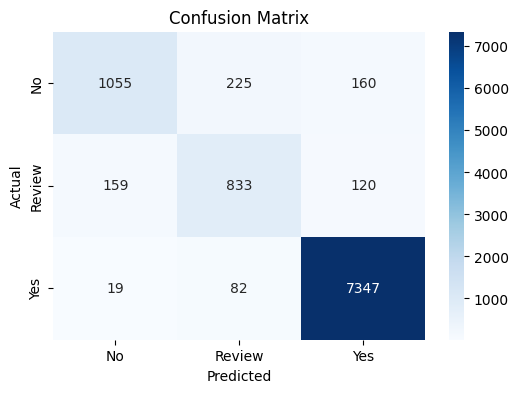

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [24]:
feature_importance = pd.DataFrame({"Feature": X.columns,"Importance": model.feature_importances_})

feature_importance = feature_importance.sort_values(by="Importance",ascending=False)

feature_importance.head(15)

,Feature,Importance
7,hours_since_prepared,42.937283
15,estimated_shelf_life_hr,40.603780
11,season,3.047554
4,packaging_type,2.946971
5,temperature_c,2.434095
3,storage_condition,1.692318
6,humidity_percent,1.372838
0,food_item,1.246107
1,food_category,1.129574
12,event_type,0.614827


In [25]:
results = pd.DataFrame({"Metric": ["Accuracy", "Weighted F1"],"Score": [0.9235, 0.92]})

results

,Metric,Score
0,Accuracy,0.9235
1,Weighted F1,0.9200


# Model Evaluation Summary

## Performance

- Accuracy: 92.35%
- Weighted F1-Score: 0.92
- Macro F1-Score: 0.83

## Key Findings

- The model successfully classifies food donations into:
  - Yes (Safe to Donate)
  - Review (Needs Inspection)
  - No (Unsafe to Donate)

- Strong performance was achieved without using the spoilage risk label as an input feature, preventing target leakage.

- The most influential factors affecting food safety were:
  - Hours Since Prepared
  - Estimated Shelf Life
  - Temperature
  - Storage Condition
  - Packaging Type

## Business Impact

This model enables NGOs and food redistribution platforms to automatically assess donation safety and reduce manual inspection efforts. The predictions can be combined with urgency scoring and smart matching to prioritize food pickups and minimize wastage.

###-----------------------------------------------------------------

# Urgency Level Prediction Model

This section creates an urgency target and trains a second CatBoost model to classify donations as Low, Medium, High, or Critical urgency.

In [26]:
df["shelf_life_used_percent"] = (df["hours_since_prepared"] / df["estimated_shelf_life_hr"]) * 100

df["shelf_life_used_percent"].describe()

,shelf_life_used_percent
count,50000.000000
mean,70.494936
std,83.945894
min,0.148810
25%,17.915484
50%,42.366376
75%,90.967126
max,1231.292517


In [27]:
df["shelf_life_used_percent"] = df["shelf_life_used_percent"].clip(upper=100)

In [28]:
df["urgency_level"] = pd.cut(df["shelf_life_used_percent"],bins=[0, 25, 50, 75, 100],labels=["Low", "Medium", "High", "Critical"])

In [29]:
df["urgency_level"].value_counts()

,count
urgency_level,
Low,16897
Critical,15500
Medium,10837
High,6766


Encoding target

In [30]:
urgency_encoder = LabelEncoder()

y_urgency = urgency_encoder.fit_transform(df["urgency_level"])

print(urgency_encoder.classes_)

['Critical' 'High' 'Low' 'Medium']


In [31]:
X_urgency = df.drop(["safe_to_donate", "urgency_level"], axis=1)

Train test split

In [32]:
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(X_urgency,y_urgency,test_size=0.2,random_state=42,stratify=y_urgency)

Model initialization

In [33]:
urgency_model = CatBoostClassifier(iterations=300,learning_rate=0.05,depth=6,loss_function="MultiClass",eval_metric="Accuracy",random_seed=42,verbose=100)

Model training and evaluation

In [34]:
urgency_model.fit(X_train_u,y_train_u,cat_features=categorical_features,eval_set=(X_test_u, y_test_u))

0:	learn: 0.9966000	test: 0.9955000	best: 0.9955000 (0)	total: 1.67s	remaining: 8m 20s
100:	learn: 0.9967750	test: 0.9965000	best: 0.9965000 (6)	total: 1m	remaining: 2m
200:	learn: 0.9981500	test: 0.9963000	best: 0.9965000 (6)	total: 1m 49s	remaining: 54s
299:	learn: 0.9986500	test: 0.9962000	best: 0.9965000 (6)	total: 2m 38s	remaining: 0us

bestTest = 0.9965
bestIteration = 6

Shrink model to first 7 iterations.


CatBoostClassifier(depth=6, eval_metric='Accuracy', iterations=300, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

# Experiment: Urgency Classification

A CatBoost urgency classifier was trained using urgency labels derived from shelf-life utilization percentage.

The model achieved 99.65% accuracy. However, this result was considered unrealistic because the target labels were directly derived from one of the input features, leading to target leakage.

Therefore, this approach was not used in the final SharePlate pipeline.

Saving the model

In [35]:
import joblib

joblib.dump(model, "shareplate_food_safety_model.pkl")
joblib.dump(label_encoder, "food_safety_label_encoder.pkl")

print("Food Safety model saved successfully.")

Food Safety model saved successfully.


Saving feature list

In [36]:
joblib.dump(X.columns.tolist(), "food_safety_features.pkl")

print("Feature list saved successfully.")

Feature list saved successfully.


# Remaining Shelf Life Prediction Model

The Food Safety Classifier predicts whether a donation is safe, unsafe, or requires review.

However, safe donations still need to be prioritized based on how much usable shelf life is left.  
To solve this, a second machine learning model is built to predict the remaining shelf life of a food donation in hours.

This model is a regression model because the output is a continuous numerical value.

In [37]:
df["remaining_shelf_life_hr"] = (df["estimated_shelf_life_hr"] - df["hours_since_prepared"])

df["remaining_shelf_life_hr"] = df["remaining_shelf_life_hr"].clip(lower=0)

df["remaining_shelf_life_hr"].describe()

,remaining_shelf_life_hr
count,50000.000000
mean,22.454854
std,33.735586
min,0.000000
25%,1.000000
50%,9.710000
75%,26.532500
max,167.750000


In [43]:
X_reg = df.drop(["safe_to_donate", "urgency_level", "remaining_shelf_life_hr"], axis=1)
y_reg = df["remaining_shelf_life_hr"]

Train test split

In [44]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

Initializing model

In [45]:
from catboost import CatBoostRegressor
reg_model = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, loss_function="RMSE", eval_metric="RMSE", random_seed=42, verbose=100)

Model training and evaluation

In [46]:
reg_model.fit(X_train_reg, y_train_reg, cat_features=categorical_features, eval_set=(X_test_reg, y_test_reg))

0:	learn: 32.0417885	test: 32.5241516	best: 32.5241516 (0)	total: 131ms	remaining: 1m 5s
100:	learn: 0.7241104	test: 0.7344169	best: 0.7344169 (100)	total: 10.5s	remaining: 41.6s
200:	learn: 0.5364209	test: 0.5521702	best: 0.5521702 (200)	total: 18.2s	remaining: 27s
300:	learn: 0.4784088	test: 0.4979269	best: 0.4979269 (300)	total: 25.5s	remaining: 16.9s
400:	learn: 0.4456515	test: 0.4713102	best: 0.4713102 (400)	total: 33.7s	remaining: 8.32s
499:	learn: 0.4249687	test: 0.4580051	best: 0.4580051 (499)	total: 40.2s	remaining: 0us

bestTest = 0.458005131
bestIteration = 499



CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
y_pred_reg = reg_model.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.24733447423647745
RMSE: 0.45800513354470196
R2 Score: 0.999819956012275


# Experiment: Remaining Shelf Life Prediction

A regression model was trained to predict remaining shelf life.

The model achieved an R² score of 0.9998. However, the target variable was directly derived from features already present in the dataset (estimated shelf life and hours since preparation), making the prediction task trivial.

Therefore, this model was not included in the final SharePlate pipeline.

# Final Model Decision

After experimentation, the Food Safety CatBoost Classifier was selected as the final machine learning model for SharePlate.

The urgency classification and remaining shelf life regression experiments were not included in the final ML pipeline because their targets were directly derived from existing input features, causing target leakage.

The final SharePlate system uses:

- CatBoostClassifier for food safety prediction
- Business logic for remaining shelf life calculation
- Urgency scoring for pickup prioritization

# Urgency Scoring Engine

The final SharePlate pipeline uses business logic to calculate urgency instead of training a separate urgency model.

This avoids target leakage and makes the prioritization system more explainable for real-world food donation operations.

In [50]:
df["urgency_score"] = ((df["hours_since_prepared"] / df["estimated_shelf_life_hr"]) * 100)

df["urgency_score"] = df["urgency_score"].clip(upper=100)

df["urgency_score"].describe()

,urgency_score
count,50000.000000
mean,50.294322
std,35.261308
min,0.148810
25%,17.915484
50%,42.366376
75%,90.967126
max,100.000000


In [51]:
df["urgency_level"] = pd.cut(df["urgency_score"], bins=[0, 25, 50, 75, 100], labels=["Low", "Medium", "High", "Critical"], include_lowest=True)

df["urgency_level"].value_counts()

,count
urgency_level,
Low,16897
Critical,15500
Medium,10837
High,6766


In [52]:
urgency_mapping = {"Low": 1,"Medium": 2,"High": 3,"Critical": 4}

df["urgency_priority"] = df["urgency_level"].map(urgency_mapping)

df[["urgency_score", "urgency_level", "urgency_priority"]].head()

,urgency_score,urgency_level,urgency_priority
0,4.003640,Low,1
1,61.472393,High,3
2,100.000000,Critical,4
3,100.000000,Critical,4
4,99.758454,Critical,4


In [53]:
df["remaining_shelf_life_hr"] = (df["estimated_shelf_life_hr"] - df["hours_since_prepared"]).clip(lower=0)

df[["estimated_shelf_life_hr", "hours_since_prepared", "remaining_shelf_life_hr", "urgency_level"]].head()

,estimated_shelf_life_hr,hours_since_prepared,remaining_shelf_life_hr,urgency_level
0,21.98,0.88,21.10,Low
1,8.15,5.01,3.14,High
2,8.82,18.60,0.00,Critical
3,27.74,28.45,0.00,Critical
4,4.14,4.13,0.01,Critical


# Final SharePlate Pipeline

The final SharePlate system combines machine learning predictions with explainable business rules.

Pipeline:

1. Food donation details are collected.
2. The CatBoost Food Safety Classifier predicts:
   - Yes (Safe)
   - Review
   - No (Unsafe)
3. Remaining shelf life is calculated using food metadata.
4. Urgency score is computed based on shelf-life utilization.
5. Donations are assigned an urgency level:
   - Low
   - Medium
   - High
   - Critical
6. Food banks and NGOs can prioritize pickups based on urgency.

In [54]:
final_output = df[[
    "food_item",
    "food_category",
    "safe_to_donate",
    "remaining_shelf_life_hr",
    "urgency_level",
    "urgency_priority"
]].head(10)

final_output

,food_item,food_category,safe_to_donate,remaining_shelf_life_hr,urgency_level,urgency_priority
0,Dal,Cooked Meal,Yes,21.10,Low,1
1,Curd,Dairy,Yes,3.14,High,3
2,Chicken Curry,Meat-Based Meal,No,0.00,Critical,4
3,Chapati,Bakery,Review,0.00,Critical,4
4,Fish Curry,Meat-Based Meal,Review,0.01,Critical,4
5,Curd,Dairy,Review,0.53,Critical,4
6,Vegetable Curry,Cooked Meal,Yes,15.90,Medium,2
7,Fresh Fruit,Produce,Yes,35.64,Low,1
8,Sandwich,Ready-to-Eat,No,0.00,Critical,4
9,Dal,Cooked Meal,No,0.00,Critical,4


In [55]:
joblib.dump(model, "shareplate_food_safety_model.pkl")
joblib.dump(label_encoder, "food_safety_label_encoder.pkl")
joblib.dump(X.columns.tolist(), "food_safety_features.pkl")

df.to_csv("shareplate_final_dataset_with_urgency.csv", index=False)

print("Final model and dataset saved successfully.")

Final model and dataset saved successfully.
